In [4]:
import scitiff

In [5]:
ob = scitiff.load_scitiff("sample_data/Isis_data/0000030174/final/0000030174_ToFImage_2to9999.tiff")

C:\Users\christianvedel\AppData\Local\Temp\ipykernel_31148\3744541940.py:1: ImageJMetadataNotFoundWarning: ImageJ metadata not found in the tiff file.
Loading the image with arbitrary dimensions...

  ob = scitiff.load_scitiff("sample_data/Isis_data/0000030174/final/0000030174_ToFImage_2to9999.tiff")
c:\Users\christianvedel\AppData\Local\miniconda3\envs\easyimaging\Lib\site-packages\scitiff\io.py:746: IncompatibleDtypeWarning: The image data does not have compatible dtype. The image has dtype of ``uint32``. The dtype will be converted to ``<class 'numpy.int64'>``.
  image_da = sc.DataArray(data=_wrap_as_arbitrary_variable(image_values))


In [6]:
data = scitiff.load_scitiff("sample_data/Isis_data/0000030192/final/0000030192_ToFImage_2to9999.tiff")

C:\Users\christianvedel\AppData\Local\Temp\ipykernel_31148\3187524337.py:1: ImageJMetadataNotFoundWarning: ImageJ metadata not found in the tiff file.
Loading the image with arbitrary dimensions...

  data = scitiff.load_scitiff("sample_data/Isis_data/0000030192/final/0000030192_ToFImage_2to9999.tiff")


In [7]:
import scipp as sc
import numpy as np

In [8]:
ob = ob['image'].rename_dims({'dim_2': 'x', 'dim_1': 'y', 'dim_0': 'tof'})
data = data['image'].rename_dims({'dim_2': 'x', 'dim_1': 'y', 'dim_0': 'tof'})

In [9]:
ob.coords['tof'] = sc.array(dims=['tof'], values=np.arange(0, ob.sizes['tof']*25, 25), unit='microsecond')
ob.coords['x'] = sc.array(dims=['x'], values=np.arange(1, ob.sizes['x']+1))
ob.coords['y'] = sc.array(dims=['y'], values=np.arange(1, ob.sizes['y']+1))
ob.coords['Ltotal'] = sc.scalar(56.5, unit='m')
data.coords['tof'] = sc.array(dims=['tof'], values=np.arange(0, data.sizes['tof']*25, 25), unit='microsecond')
data.coords['x'] = sc.array(dims=['x'], values=np.arange(1, data.sizes['x']+1))
data.coords['y'] = sc.array(dims=['y'], values=np.arange(1, data.sizes['y']+1))
data.coords['Ltotal'] = sc.scalar(56.5, unit='m')

In [10]:
ob

<scipp.DataArray>
Dimensions: Sizes[tof:4000, y:512, x:512, ]
Coordinates:
* Ltotal                    float64              [m]  ()  56.5
* tof                         int64            [µs]  (tof)  [0, 25, ..., 99950, 99975]
* x                           int64  [dimensionless]  (x)  [1, 2, ..., 511, 512]
* y                           int64  [dimensionless]  (y)  [1, 2, ..., 511, 512]
Data:
                              int64  [dimensionless]  (tof, y, x)  [0, 0, ..., 0, 0]

In [11]:
lower_x = sc.scalar(40)
upper_x = sc.scalar(470)
lower_y = sc.scalar(120)
upper_y = sc.scalar(320)

# Full pixel-resolution

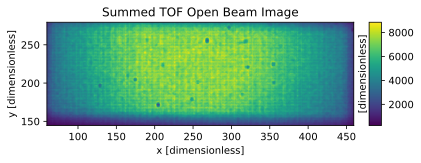

In [464]:
ob['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Summed TOF Open Beam Image")

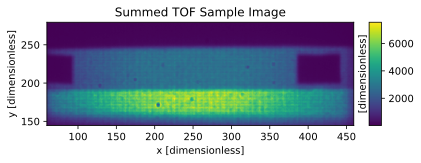

In [465]:
data['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Summed TOF Sample Image")

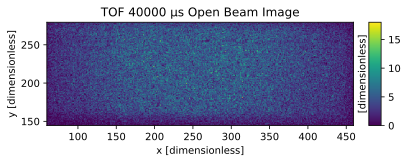

In [466]:
ob['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(40000, unit='microsecond')].plot(aspect='equal', title="TOF 40000 µs Open Beam Image")

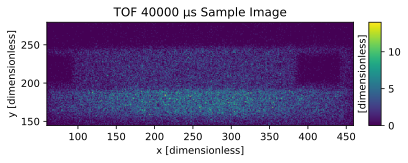

In [467]:
data['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(40000, unit='microsecond')].plot(aspect='equal', title="TOF 40000 µs Sample Image")

# Histogrammed in space

In [430]:
pixel_resolution = 128
tof_resolution = sc.scalar(250, unit='microsecond')

In [431]:
hist_ob = ob.hist(y=pixel_resolution).hist(x=pixel_resolution).hist(tof=tof_resolution)
hist_ob

<scipp.DataArray>
Dimensions: Sizes[y:128, x:128, tof:400, ]
Coordinates:
* Ltotal                    float64              [m]  ()  56.5
* tof                         int64            [µs]  (tof [bin-edge])  [0, 250, ..., 99750, 100000]
* x                           int64  [dimensionless]  (x [bin-edge])  [1, 5, ..., 509, 513]
* y                           int64  [dimensionless]  (y [bin-edge])  [1, 5, ..., 509, 513]
Data:
                              int64  [dimensionless]  (y, x, tof)  [0, 0, ..., 0, 0]

In [432]:
hist_data = data.hist(y=pixel_resolution).hist(x=pixel_resolution).hist(tof=tof_resolution)
hist_data

<scipp.DataArray>
Dimensions: Sizes[y:128, x:128, tof:400, ]
Coordinates:
* Ltotal                    float64              [m]  ()  56.5
* tof                         int64            [µs]  (tof [bin-edge])  [0, 250, ..., 99750, 100000]
* x                           int64  [dimensionless]  (x [bin-edge])  [1, 5, ..., 509, 513]
* y                           int64  [dimensionless]  (y [bin-edge])  [1, 5, ..., 509, 513]
Data:
                              int64  [dimensionless]  (y, x, tof)  [0, 0, ..., 0, 0]

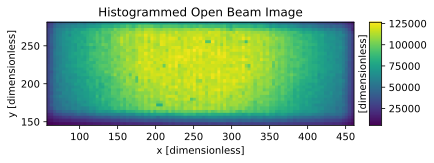

In [433]:
hist_ob['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Histogrammed Open Beam Image")

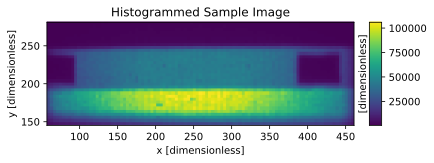

In [434]:
hist_data['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Histogrammed Sample Image")

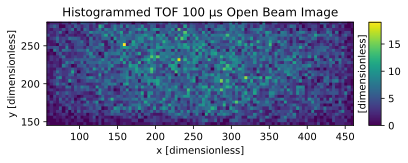

In [435]:
hist_ob['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(4000, unit='microsecond')].plot(aspect='equal', title="Histogrammed TOF 100 µs Open Beam Image")

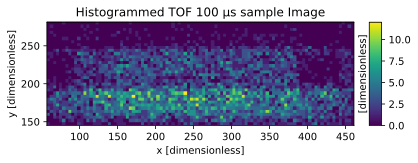

In [436]:
hist_data['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(4000, unit='microsecond')].plot(aspect='equal', title="Histogrammed TOF 100 µs sample Image")

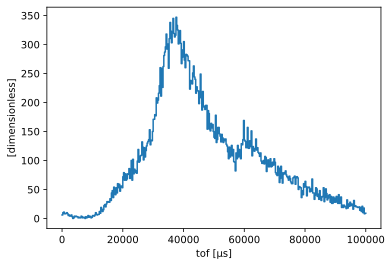

In [437]:
hist_data['x', sc.scalar(150)]['y', sc.scalar(220)].plot(linestyle='solid', marker=None)

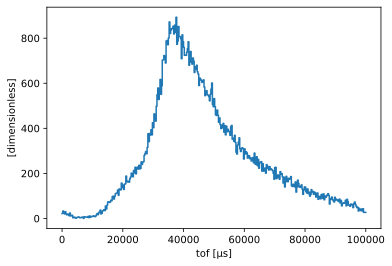

In [438]:
hist_ob['x', sc.scalar(150)]['y', sc.scalar(220)].plot(linestyle='solid', marker=None)

In [439]:
hist_normalized = hist_data / hist_ob

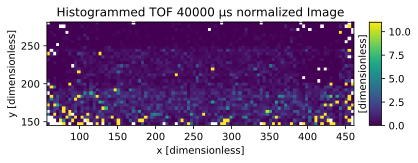

In [440]:
hist_normalized['x', lower_x:upper_x]['y', lower_y:upper_y]['tof',sc.scalar(4000, unit='microsecond')].plot(aspect='equal', title="Histogrammed TOF 40000 µs normalized Image")

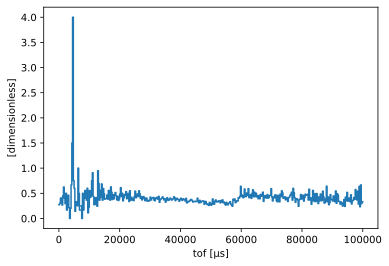

In [441]:
hist_normalized_spectrum = hist_normalized['x', sc.scalar(150)]['y', sc.scalar(220)]
# hist_normalized_spectrum = hist_normalized['x', 9]['y', 55]
hist_normalized_spectrum.plot(linestyle='solid', marker=None)

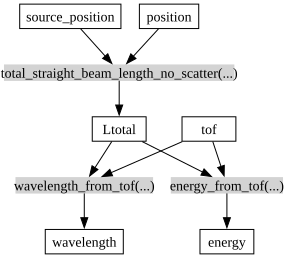

In [442]:
from scippneutron.conversion import graph


PLAIN_GRAPH = {**graph.beamline.beamline(False), **graph.tof.kinematic("tof")}
sc.show_graph(PLAIN_GRAPH)

In [443]:
hist_spectrum_lambda = hist_normalized_spectrum.transform_coords('wavelength', graph=PLAIN_GRAPH)

In [444]:
lambda_lower = 3.0 * sc.Unit('Å')
lambda_upper = 5.0 * sc.Unit('Å')

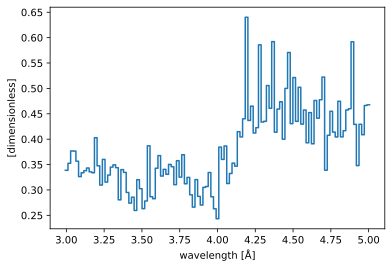

In [445]:
hist_spectrum_lambda['wavelength', lambda_lower:lambda_upper].plot()

In [446]:
sliced_spectrum = hist_spectrum_lambda['wavelength', lambda_lower:lambda_upper]

In [447]:
wavelengths = sc.midpoints(sliced_spectrum.coords['wavelength']).values
transmissions = sliced_spectrum.values

In [448]:
import NCrystal
import NCrystal.plot
import matplotlib.pyplot as plt
import numpy as np

## Bragg-edge fitting with Ncrystal and EasyScience

In [449]:
from easyscience.Objects.variable import Parameter
from easyscience.Objects.ObjectClasses import BaseObj
from easyscience.fitting import Fitter

### Setting up the fitting models

Defining the fitting parameters and their initial values

In [450]:
lattice_constant =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=1,  max=4,    fixed=False)
debye_temperature = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=250,  max=800,  fixed=False)
temperature =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=1,  max=600,  fixed=False)
intensity_scale =   Parameter(name="Intensity scale factor",    value=0.05,                      fixed=False)

Defining the fit functions to go into EasyScience

In [451]:
def iron_bragg(wavelength):
    # Initalize the NCrystal material composer
    material = NCrystal.NCMATComposer()
    # Set the material parameters with the fitting variables
    material.set_cellsg_cubic(lattice_constant.value)
    material.set_atompos([  ('Fe',0,0,0),
                            ('Fe',0.5, 0.5, 0.5),
                            ])
    material.set_dyninfo_debyetemp("Fe", debye_temp=debye_temperature.value)
    material.set_default_temperature(temperature.value)

    # Identify the space group from atomic positions
    material.refine_crystal_structure(quiet=True)

    #print("lattice constant:", lattice_constant.value)
    scatter = material.load()

    # Create scattering spectrum
    spectrum = np.exp(-intensity_scale.value*(scatter.scatter.xsect(wl=wavelength) + scatter.absorption.xsect(wl=wavelength)))
    if np.any(np.isnan(spectrum)):
        print("Warning: NaN values in spectrum")
    return spectrum

Make the EasyScience container for the fitting parameters

In [452]:
iron_spectrum = BaseObj(
                        name='Iron transmission spectrum', 
                        lattice_constant=lattice_constant, 
                        debye_temperature=debye_temperature,
                        temperature=temperature,
                        intensity_scale=intensity_scale,
                        )

## Fitting

Make the EasyScience fitting objects

In [453]:
fitter = Fitter(iron_spectrum, iron_bragg)
fitter.max_evaluations = 200

For the fits in this notebook, we will use "LMFit_leastsq" which is a standard leastsquares fitting method

In [454]:
fitter.switch_minimizer("LMFit_leastsq")

minimizer should be set with enum LMFit_leastsq


### Performing the actual Fit

In [455]:
# Parameters for LMFit_leastsq
results = fitter.fit(x=wavelengths, y=transmissions, 
                     #weights=1/np.sqrt(variances), 
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                    #max_nfev=10000
                     )

NCrystal WARNING: Discarding 19 edges of provided kernel data due to missing S values.


Print the fitted values

In [456]:
print(lattice_constant)
print(debye_temperature)
print(temperature)
print(intensity_scale)

<Parameter 'Lattice constant': 2.8683 ± 0.0044 Å, bounds=[1.0:4.0]>
<Parameter 'Debye temperature': 250.3258 ± 243.6191 K, bounds=[250.0:800.0]>
<Parameter 'Temperature': 539.7119 ± 9627.5213 K, bounds=[1.0:600.0]>
<Parameter 'Intensity scale factor': 0.0760 ± 0.0166, bounds=[-inf:inf]>


In [457]:
dir(results)

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 'chi2',
 'engine_result',
 'fit_args',
 'minimizer_engine',
 'n_pars',
 'p',
 'p0',
 'reduced_chi',
 'residual',
 'success',
 'total_results',
 'x',
 'x_matrices',
 'y_calc',
 'y_err',
 'y_obs']

### Comparing the fitted model and data

First we need to calculate the spectra with the fitted model

In [458]:
simulated = iron_bragg(wavelengths)

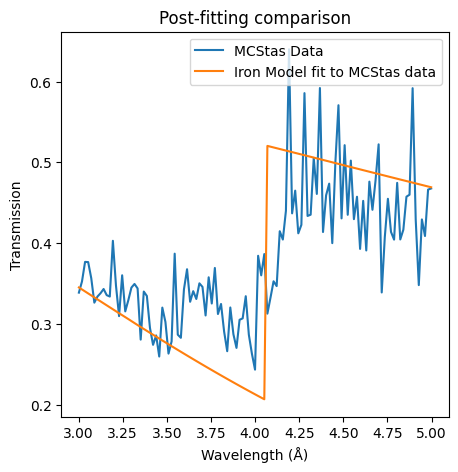

In [459]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='MCStas Data')
plt.plot(wavelengths, simulated, label="Iron Model fit to MCStas data")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Transmission")
plt.title("Post-fitting comparison")
plt.legend()
plt.show()

# Fit per pixel

In [493]:
lower_x = sc.scalar(100)
upper_x = sc.scalar(380)
lower_y = sc.scalar(200)
upper_y = sc.scalar(240)

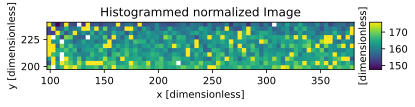

In [494]:
hist_normalized['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof').plot(aspect='equal', title="Histogrammed normalized Image")

In [495]:
lattice_constants = sc.zeros_like(hist_normalized['x', lower_x:upper_x]['y', lower_y:upper_y].sum('tof'))
lattice_constants.shape

(11, 71)

In [361]:
hist_normalized_lambda = hist_normalized['x', lower_x:upper_x]['y', lower_y:upper_y].transform_coords('wavelength', graph=PLAIN_GRAPH)

In [362]:
sliced_normalized = hist_normalized_lambda['wavelength', lambda_lower:lambda_upper]

In [363]:
for xi in range(sliced_normalized.sizes['x']):
    for yi in range(sliced_normalized.sizes['y']):
        hist_spectrum = sliced_normalized['x', xi]['y', yi]
        transmissions = hist_spectrum.values
        if not np.isfinite(transmissions).all():
            print(f"Skipping pixel x={xi}, y={yi} due to NaNs")
            continue
        if (transmissions == 0.0).any():
            print(f"Skipping pixel x={xi}, y={yi} due to zero transmissions")
            continue
        print(f"Fitting pixel x={xi}, y={yi}")
        lattice_constant =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=0,  max=4,    fixed=False)
        debye_temperature = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=250,  max=800,  fixed=False)
        temperature =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=0,  max=600,  fixed=False)
        intensity_scale =   Parameter(name="Intensity scale factor",    value=0.05,                      fixed=False)

        iron_spectrum = BaseObj(
                        name='Iron transmission spectrum', 
                        lattice_constant=lattice_constant, 
                        debye_temperature=debye_temperature,
                        temperature=temperature,
                        intensity_scale=intensity_scale,
                        )

        fitter = Fitter(iron_spectrum, iron_bragg)
        fitter.max_evaluations = 100
        fitter.switch_minimizer("LMFit_leastsq")
        results = fitter.fit(x=wavelengths, y=transmissions,
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                     )
        if results.success:
            lattice_constants['x', xi]['y', yi] = lattice_constant.value
        else:
            lattice_constants['x', xi]['y', yi] = np.nan

Skipping pixel x=0, y=0 due to NaNs
Skipping pixel x=0, y=1 due to NaNs
Skipping pixel x=0, y=2 due to NaNs
Skipping pixel x=0, y=3 due to NaNs
Skipping pixel x=0, y=4 due to zero transmissions
Skipping pixel x=0, y=5 due to zero transmissions
Skipping pixel x=0, y=6 due to zero transmissions
Skipping pixel x=0, y=7 due to zero transmissions
Fitting pixel x=0, y=8
minimizer should be set with enum LMFit_leastsq
NCrystal WARNING: Discarding 31 edges of provided kernel data due to missing S values.
Skipping pixel x=0, y=9 due to zero transmissions
Fitting pixel x=0, y=10
minimizer should be set with enum LMFit_leastsq
Skipping pixel x=0, y=11 due to zero transmissions
Skipping pixel x=0, y=12 due to zero transmissions
Skipping pixel x=0, y=13 due to zero transmissions
Fitting pixel x=0, y=14
minimizer should be set with enum LMFit_leastsq
Skipping pixel x=0, y=15 due to zero transmissions
Skipping pixel x=0, y=16 due to zero transmissions
Skipping pixel x=0, y=17 due to zero transmission

KeyboardInterrupt: 

In [257]:
sliced_normalized['x', 9]['y', 55]

<scipp.DataArray>
Dimensions: Sizes[wavelength:115, ]
Coordinates:
  Ltotal                    float64              [m]  ()  56.5
  tof                         int64            [µs]  (wavelength [bin-edge])  [42750, 43000, ..., 71250, 71500]
* wavelength                float64             [Å]  (wavelength [bin-edge])  [2.99328, 3.01079, ..., 4.9888, 5.00631]
  x                           int64  [dimensionless]  (x [bin-edge])  [37, 41]
  y                           int64  [dimensionless]  (y [bin-edge])  [221, 225]
Data:
                            float64  [dimensionless]  (wavelength)  [0.222222, 0.0833333, ..., 0.5, 0]

In [256]:
np.isfinite(sliced_normalized['x', 9]['y', 55].values).all()

np.True_

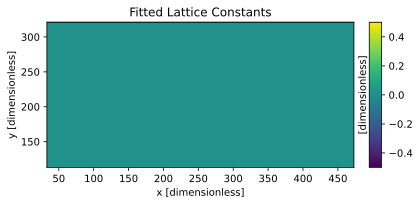

In [359]:
lattice_constants.plot(aspect='equal', title="Fitted Lattice Constants")